<a href="https://colab.research.google.com/github/sans0726/100-days-of-deep-learning/blob/main/LSTM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Simple sequence
X = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6],
    [5, 6, 7]
])

y = np.array([4, 5, 6, 7, 8])

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]

y:
[4 5 6 7 8]


In [2]:
# Reshape data for LSTM
X_lstm = X.reshape((X.shape[0], X.shape[1], 1))

print("Original shape:", X.shape)
print("LSTM input shape:", X_lstm.shape)

print("\nFirst sample:")
print(X_lstm[0])

Original shape: (5, 3)
LSTM input shape: (5, 3, 1)

First sample:
[[1]
 [2]
 [3]]


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(10, input_shape=(3, 1)),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer="adam",
    loss="mse"
)

print("Model compiled successfully!")

Model compiled successfully!


In [5]:
history = model.fit(
    X_lstm,
    y,
    epochs=100,
    verbose=0
)

print("Training completed!")
print("Final loss:", history.history["loss"][-1])

Training completed!
Final loss: 17.376720428466797


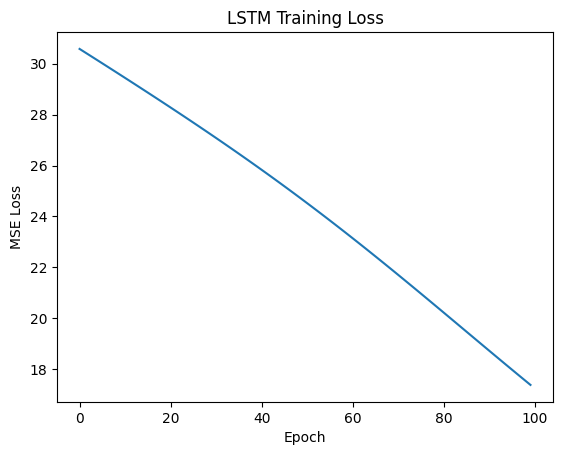

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Loss")
plt.show()

In [7]:
predictions = model.predict(X_lstm, verbose=0)

print("Actual values:    ", y)
print("Predicted values: ", predictions.flatten())

Actual values:     [4 5 6 7 8]
Predicted values:  [1.6590815 1.9642459 2.1220064 2.1974847 2.2248244]


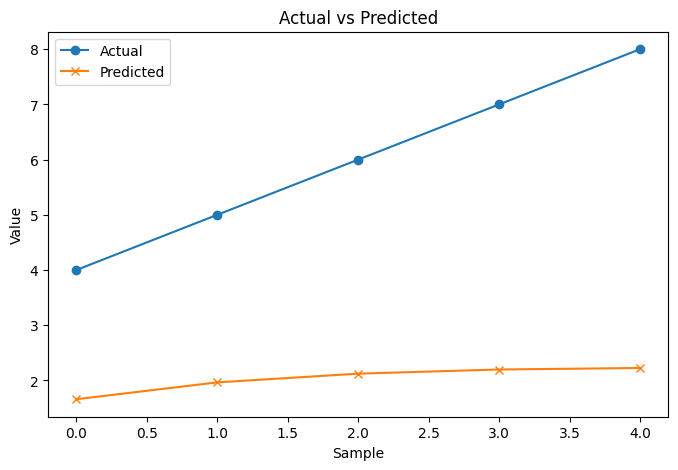

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(y, marker="o", label="Actual")
plt.plot(predictions.flatten(), marker="x", label="Predicted")

plt.xlabel("Sample")
plt.ylabel("Value")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()